In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
import os
import math

In [7]:
data = pd.read_csv("clean_weather.csv", index_col=0)
data = data.ffill()

data.head(5)

,tmax,tmin,rain,tmax_tomorrow
1970-01-01,60.0,35.0,0.0,52.0
1970-01-02,52.0,39.0,0.0,52.0
1970-01-03,52.0,35.0,0.0,53.0
1970-01-04,53.0,36.0,0.0,52.0
1970-01-05,52.0,35.0,0.0,50.0


In [8]:
data.shape

(13509, 4)

<Axes: xlabel='tmax', ylabel='tmax_tomorrow'>

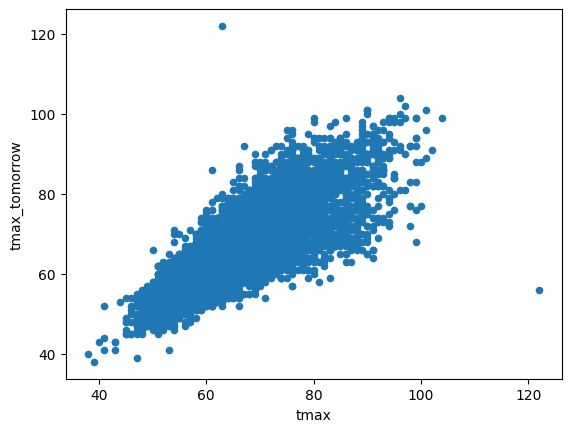

In [9]:
data.plot.scatter("tmax", "tmax_tomorrow")

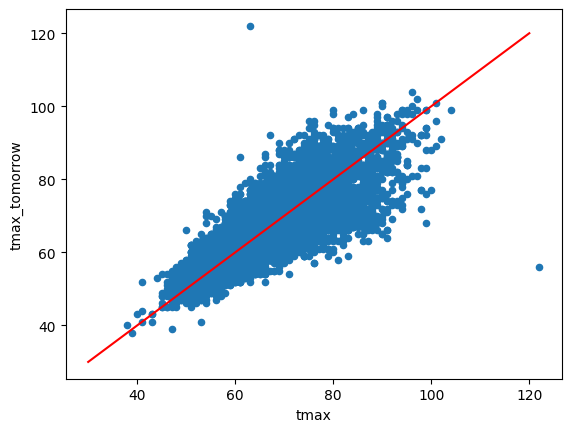

In [10]:
data.plot.scatter("tmax", "tmax_tomorrow")
plt.plot([30, 120], [30,120], 'red')

$\hat_{y} = w_{1} * x_{1} + b$
$\hat_{y} = w_{1} * x_{1}+ w_{2} * x_{2} + b$

In [11]:
1*80 + 1

81

In [12]:
lr = LinearRegression()
lr.fit(data[["tmax"]], data["tmax_tomorrow"])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


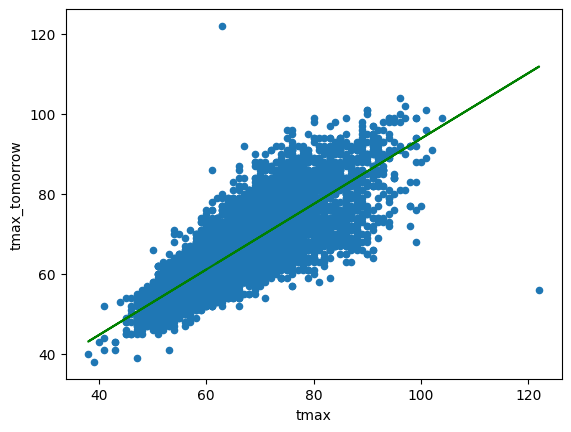

In [13]:
data.plot.scatter("tmax", "tmax_tomorrow")
plt.plot(data["tmax"], lr.predict(data[["tmax"]]), "green")

In [14]:
print(f"weight: {lr.coef_[0]: .2f}")
print(f"Bias: {lr.intercept_:2f}")

weight:  0.82
Bias: 11.986561


In [15]:
.82 * 80 + 11.99

77.58999999999999

# MEASURING LOSS

$\text{MSE}=(\hat_{y} - y) ^2$

In [16]:
(77.58-81.0) ** 2

11.696400000000011

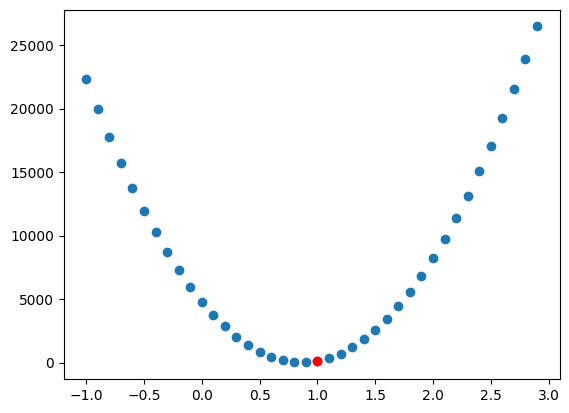

In [17]:
loss = lambda w, y: ((w * 80 + 11.69) - y)**2
y = 81

w8 = np.arange(-1, 3, .1)
losses = loss(w8, y)

plt.scatter(w8, losses)
plt.plot(1, loss(1,y), 'ro')

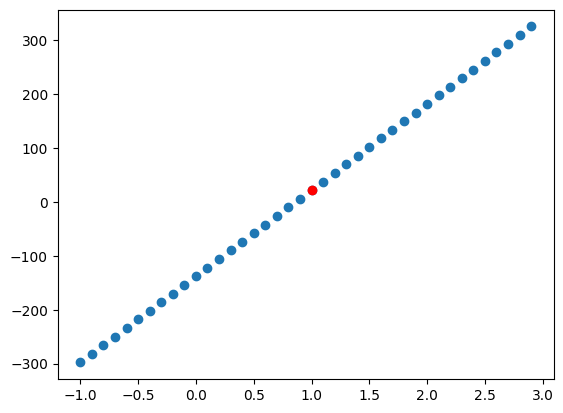

In [18]:
#Graient is the derivative of the loss function 
gradient = lambda w, y: ((w * 80 + 11.99) - y) * 2
gradients = gradient(w8, y)

plt.scatter(w8, gradients)
plt.plot(1, gradient(1,y), 'ro')

## Gradients and Patial Derivatives

In [19]:
2* (((80*1) + 11.99) - 81)

21.97999999999999

$$
\frac{\partial L}{\partial b} = \partial L
$$

$$
\frac{\partial L}{\partial w} = \frac{\partial L}{\partial (xw)} \frac{\partial (xw)}{\partial w}
$$

In [20]:
os.listdir()

['.ipynb_checkpoints',
 'clean_weather.csv',
 'Gradient_Decent.ipynb',
 'w_deriv.svg']

In [21]:
![w_derivative](w_deriv.svg)

'[w_derivative]' is not recognized as an internal or external command,
operable program or batch file.


In [22]:
21.98 * 80

1758.4

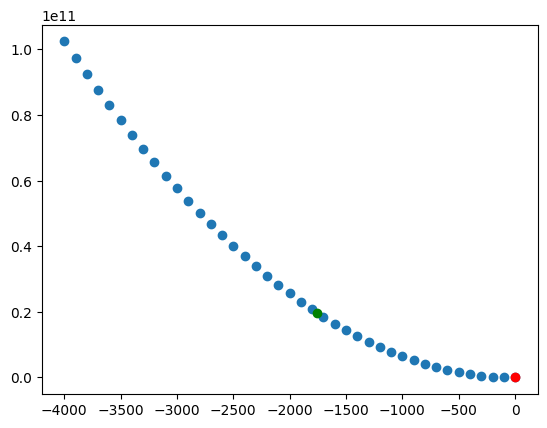

In [23]:
w8 = np.arange(-4000, 100, 100)
losses = loss(w8, y)

plt.scatter(w8, losses)

plt.plot(1, loss(1,y ), 'ro')
new_weight = 1 - gradient (1, y) * 80
plt.plot(new_weight, loss(new_weight, y), 'go')

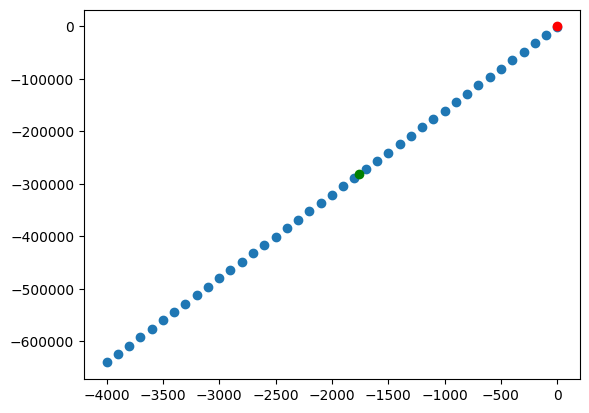

In [24]:
#Calculate gradient values for several weights
gradients = gradient(w8, y)

#plot the weight and gradients
plt.scatter(w8, gradients)
plt.plot(1, gradient(1,y), 'ro')

#New Weight
plt.plot(new_weight, gradient(new_weight, y), 'go')

## Learning Rate

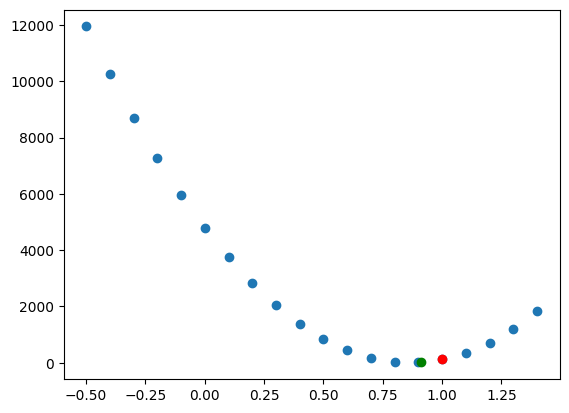

In [27]:
w8 = np.arange(-.5, 1.5, .1)
losses = loss(w8, y)

plt.scatter(w8, losses)

plt.plot(1, loss(1, y), 'ro')
lr = 5e-5
new_weight = 1 - lr * gradient (1, y) * 80
plt.plot(new_weight, loss(new_weight, y), 'go')

 You can see the Red Dot over here so when we reduced our step size we
actually move towards the point where the loss is lower so our new loss is now lower than our old loss because we used a learning rate to take a very very small step instead of a giant step so basically we were moving in the right direction we just moved way too far before and the learning rate helps us move less far so we don't get to a place where error actually increases okay and we can take a look at our new weight
and it's now 0.91 so it's it's moved down but it's still not quite at the optimal weight and this happens with gradient descent gradient descent is what's called an iterative algorithm so You need to run it multiple times to actually converge towards the point where loss is the lowest

In [28]:
new_weight

0.91208

## IMPLEMENT LINEAR REGRESSION

In [40]:
PREDICTORS = ["tmax", "tmin", "rain"]
TARGET = "tmax_tomorrow"

np.random.seed(0)
split_data = np.split(data, [int(.7 * len(data)), int(.85 * len (data))])

split_data = [train, valid, test]
(train_x, train_y), (valid_x, valid_y), (test_x, test_y) = [
    [d[PREDICTORS].to_numpy(), d[[TARGET]].to_numpy()]
    for d in split_data
]

C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:54: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [43]:
def init_params(predictors):
    np.random.seed(0)
    weights = np.random.rand(predictors, 1)
    bias = np.ones((1, 1))
    return [weights, bias]


In [44]:
init_params(3)

[array([[0.5488135 ],
        [0.71518937],
        [0.60276338]]),
 array([[1.]])]

w1 * tmax + w2 *tmin + w3 * rain +b

In [47]:
def forward (params, x):
    weights, biases = params
    prediction = x @ weights + biases
    return prediction

In [48]:
def mse (actual, predicted):
    return np.mean((actual-predicted)** 2)
def mse_grad(actual, predicted):
    return predicted - actual

In [49]:
def backward (params, x, lr, grad):
    #xl * g , x2 * 2, x3 * g
    w_grad = (x.T/x.shape[0]) @ grad
    b_grad = np.mean (grad, axis = 0)

    params[0] -= w_grad * lr
    params[1] -= b_grad * lr

    return params

# TRAINING LOOP

In [52]:
lr = 1e-4
epochs = 100

params = init_params(train_x.shape[1])

for i in range(epochs):
    predictions = forward(params, train_x)
    grad = mse_grad(train_y, predictions)

    params = backward(params, train_x, lr, grad)

    if i % 10 == 0:
        predictions = forward(params, valid_x)
        valid_loss = mse(valid_y, predictions)

        print(f"Epoch {i} loss: {valid_loss}")

Epoch 0 loss: 31.564020597420285
Epoch 10 loss: 30.661955998370296
Epoch 20 loss: 30.380247115408295
Epoch 30 loss: 30.10887251106309
Epoch 40 loss: 29.847483613647498
Epoch 50 loss: 29.595702706996423
Epoch 60 loss: 29.3531665755598
Epoch 70 loss: 29.119525943717484
Epoch 80 loss: 28.894444936524234
Epoch 90 loss: 28.67760056140068


In [53]:
params

[array([[0.53298359],
        [0.58304453],
        [0.60133   ]]),
 array([[0.99974731]])]